# 09. Trial-level Behavior Variability

Goal:
- Use trial_meta to analyze trial-level paddle responses.
- Compute condition-wise behavioral variability.
- Test whether MC-derived uncertainty or task-difficulty variables explain trial-to-trial behavioral variability.

Key question:
Does probabilistic / uncertainty-based model explain not only mean behavior but also trial-level behavioral variability?

In [2]:
from pathlib import Path
import sys
import types
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
HAND_DMFC_DIR = RAW_DIR / "hand_dmfc"
PROCESSED_DIR = DATA_DIR / "processed"

MAHLER_PKL = HAND_DMFC_DIR / "mahler_hand_dmfc_dataset_50ms.pkl"
BEHAVIOR_MODEL_PATH = PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv"

print("MAHLER_PKL exists:", MAHLER_PKL.exists())
print("BEHAVIOR_MODEL_PATH exists:", BEHAVIOR_MODEL_PATH.exists())

MAHLER_PKL exists: True
BEHAVIOR_MODEL_PATH exists: True


In [3]:
def patch_old_pandas_pickle():
    module_name = "pandas.core.indexes.numeric"
    
    if module_name not in sys.modules:
        numeric_module = types.ModuleType(module_name)
        numeric_module.Int64Index = pd.Index
        numeric_module.UInt64Index = pd.Index
        numeric_module.Float64Index = pd.Index
        sys.modules[module_name] = numeric_module


def load_pickle_compat(path: Path):
    patch_old_pandas_pickle()
    with open(path, "rb") as f:
        return pickle.load(f)


data = load_pickle_compat(MAHLER_PKL)

print("top-level keys:")
for k in data.keys():
    print(" -", k)

top-level keys:
 - trial_meta
 - neural_meta
 - neural_responses
 - neural_responses_sh1
 - neural_responses_sh2
 - behavioral_responses
 - masks
 - ntr_vis
 - ntr_occ
 - meta
 - neural_idx_global
 - conds_ch_dict
 - reliable_neural_idx
 - neural_responses_reliable
 - neural_responses_reliable_sh1
 - neural_responses_reliable_sh2
 - neural_responses_reliable_FactorAnalysis_10
 - neural_responses_reliable_FactorAnalysis_10_sh1
 - neural_responses_reliable_FactorAnalysis_10_sh2
 - neural_responses_reliable_FactorAnalysis_20
 - neural_responses_reliable_FactorAnalysis_20_sh1
 - neural_responses_reliable_FactorAnalysis_20_sh2
 - neural_responses_reliable_FactorAnalysis_50
 - neural_responses_reliable_FactorAnalysis_50_sh1
 - neural_responses_reliable_FactorAnalysis_50_sh2


In [4]:
trial_meta = data["trial_meta"].copy()
meta = data["meta"].copy()

print("trial_meta shape:", trial_meta.shape)
print("meta shape:", meta.shape)

display(trial_meta.head())
display(meta.head())

trial_meta shape: (10158, 87)
meta shape: (79, 88)


,py_meta_index,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe
0,273515.0,1.00,1.0,-1.6,7.8,26.577181,7.50,1.0,0.0,0.0,6.97,0.0,1.0,0.0,-1.6,7.8,26.577181,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.718458,6.251542,9.614858,6.306340,10.0,6.80,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,21.756443,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,13.44,28.48,273515.0,1.0,24.844538,-1.6,7.8,5.527836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.97,1.442164,1.442164,0.010603,2.755324e+08,42940.500000,1.0,0.139905,162.786017,355,55,26,2.755324e+08,42914.500000,2.755320e+08,42585.500000,2.755323e+08,42885.500000
1,377134.0,0.95,1.0,-0.2,-6.6,42.040268,7.50,1.0,0.0,0.0,2.89,0.0,1.0,0.0,-0.2,-6.6,42.040268,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.533361,2.356639,9.640471,2.272931,10.0,2.72,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-8.698303,0.733741,32.0,32.0,0.901677,0.0,8.0,0.50,15.68,5.44,377134.0,0.0,20.172360,-0.2,-6.6,2.607725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.89,0.282275,0.282275,0.010603,2.755427e+08,53214.433333,1.0,0.139905,162.786017,364,64,35,2.755426e+08,53179.433333,2.755423e+08,52850.433333,2.755426e+08,53150.433333
2,187617.0,1.00,1.0,-3.0,-8.8,-28.510067,7.50,1.0,0.0,0.0,-2.38,0.0,1.0,0.0,-3.0,-8.8,-28.510067,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.389849,-3.769849,10.124887,-3.828534,10.0,-2.21,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,8.003652,-0.497595,32.0,32.0,-0.543183,1.0,8.0,0.50,11.20,1.92,187617.0,1.0,10.815516,-3.0,-8.8,-3.240303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.38,0.860303,0.860303,0.010603,2.755461e+08,56628.966667,1.0,0.139905,162.786017,367,67,38,2.755460e+08,56590.966667,2.755457e+08,56261.966667,2.755460e+08,56561.966667
3,77046.0,1.00,1.0,-5.6,-2.8,30.442953,7.50,0.0,1.0,0.0,2.38,0.0,1.0,0.0,-5.6,-2.8,30.442953,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,4.193585,6.573585,10.241714,6.510249,10.0,2.38,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,7.382559,0.531330,32.0,32.0,0.587705,1.0,8.0,0.50,7.04,11.52,77046.0,0.0,26.213726,-5.6,-2.8,6.383579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,4.003579,-4.003579,0.010603,2.755499e+08,60437.466667,1.0,0.139905,162.786017,358,58,29,2.755499e+08,60408.466667,2.755495e+08,60079.466667,2.755498e+08,60379.466667
4,248856.0,0.95,1.0,-1.8,-8.4,49.771812,11.25,0.0,1.0,0.0,2.72,0.0,1.0,0.0,-1.8,-8.4,49.771812,11.25,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,3.195214,5.915214,10.188274,5.772059,10.0,2.55,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-12.949939,0.868682,32.0,32.0,1.182160,0.0,8.0,0.75,13.12,2.56,248856.0,0.0,24.891743,-1.8,-8.4,5.557339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.72,2.837339,-2.837339,

,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe,dx,dy,py_meta_index
py_meta_index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
29337,0.993310,1.0,-7.0,-8.8,26.577181,7.50,0.654930,0.190141,0.154930,-0.676408,0.0,1.0,0.0,-7.0,-8.8,26.577181,7.50,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.970806,-0.339536,9.881309,-0.354878,10.0,-0.578239,-22.0,12.0,2.021112e+07,-0.481270,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,4.80,1.92,29337.0,0.0,15.565790,-7.0,-8.8,-0.271381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.676408,1.016034,-0.405027,0.012477,2.739755e+08,4.265471e+06,1.0,0.167588,131.546784,362.514085,62.514085,47.253521,2.739755e+08,4.265424e+06,2.739752e+08,4.265109e+06,2.739755e+08,4.265409e+06,6.707494,3.355522,29337
55062,0.991935,1.0,-6.2,-4.4,-32.375839,7.50,0.612903,0.370968,0.016129,-3.937419,0.0,1.0,0.0,-6.2,-4.4,-32.375839,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.743791,-5.027263,9.917711,-5.093503,10.0,-3.868871,-22.0,12.0,2.021112e+07,12.814890,-0.565065,32.0,32.0,-0.634028,0.0,8.0,0.50,6.08,8.96,55062.0,1.0,8.919592,-6.2,-4.4,-4.425255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.937419,1.599905,0.487836,0.012379,2.630043e+08,4.079111e+06,1.0,0.167680,132.054942,362.758065,62.758065,47.266129,2.630043e+08,4.079064e+06,2.630039e+08,4.078749e+06,2.630042e+08,4.079049e+06,6.334154,-4.016030,55062
58244,0.991057,1.0,-6.2,4.2,-32.375839,7.50,0.699187,0.260163,0.040650,-5.499431,0.0,1.0,0.0,-6.2,4.2,-32.375839,7.50,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.348329,-6.019615,9.803604,-5.946732,10.0,-5.518781,-22.0,12.0,2.021112e+07,26.574890,-0.565065,32.0,32.0,-0.634028,1.0,8.0,0.50,6.08,22.72,58244.0,0.0,6.120408,-6.2,4.2,-6.174745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.499431,1.400058,0.675314,0.012438,2.580445e+08,4.162581e+06,1.0,0.168136,132.329554,362.674797,62.674797,47.008130,2.580445e+08,4.162534e+06,2.580441e+08,4.162218e+06,2.580444e+08,4.162518e+06,6.334154,-4.016030,58244
59920,0.992735,1.0,-6.2,8.6,-48.805369,11.25,0.410256,0.529915,0.059829,-7.019402,0.0,1.0,0.0,-6.2,8.6,-48.805369,11.25,1.0,5.0,5.0,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,2.427825,-9.404458,9.984960,-9.553176,10.0,-7.028120,-22.0,12.0,2.021112e+07,36.706441,-0.851814,32.0,32.0,-1.142507,1.0,8.0,0.75,6.08,29.76,59920.0,1.0,1.430946,-6.2,8.6,-9.105659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.019402,2.133472,2.086257,0.012194,2.671821e+08,4.219482e+06,1.0,0.166494,132.008104,361.991453,61.991453,46.170940,2.671820e+08,4.219436e+06,2.671817e+08,4.219120e+06,2.671820e+08,4.219420e+06,7.409463,-8.465362,59920
68220,0.991797,1.0,-5.8,-6.4,37.208054,7.50,0.742188,0.210938,0.046875,5.084062,0.0,1.0,0.0,-5.8,-6.4,37.208054,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-1

In [5]:
beh_cond = pd.read_csv(BEHAVIOR_MODEL_PATH)

valid_meta_indices = set(meta["meta_index"].astype(float)) if "meta_index" in meta.columns else set(meta.index.astype(float))

trial_df = trial_meta.copy()

# Ensure meta_index column exists
if "meta_index" not in trial_df.columns and "py_meta_index" in trial_df.columns:
    trial_df["meta_index"] = trial_df["py_meta_index"]

trial_df = trial_df[trial_df["meta_index"].astype(float).isin(valid_meta_indices)].copy()

print("trial_df shape after meta_index filter:", trial_df.shape)
print("unique conditions:", trial_df["meta_index"].nunique())

display(trial_df.head())

trial_df shape after meta_index filter: (10158, 87)
unique conditions: 79


,py_meta_index,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe
0,273515.0,1.00,1.0,-1.6,7.8,26.577181,7.50,1.0,0.0,0.0,6.97,0.0,1.0,0.0,-1.6,7.8,26.577181,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.718458,6.251542,9.614858,6.306340,10.0,6.80,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,21.756443,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,13.44,28.48,273515.0,1.0,24.844538,-1.6,7.8,5.527836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.97,1.442164,1.442164,0.010603,2.755324e+08,42940.500000,1.0,0.139905,162.786017,355,55,26,2.755324e+08,42914.500000,2.755320e+08,42585.500000,2.755323e+08,42885.500000
1,377134.0,0.95,1.0,-0.2,-6.6,42.040268,7.50,1.0,0.0,0.0,2.89,0.0,1.0,0.0,-0.2,-6.6,42.040268,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.533361,2.356639,9.640471,2.272931,10.0,2.72,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-8.698303,0.733741,32.0,32.0,0.901677,0.0,8.0,0.50,15.68,5.44,377134.0,0.0,20.172360,-0.2,-6.6,2.607725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.89,0.282275,0.282275,0.010603,2.755427e+08,53214.433333,1.0,0.139905,162.786017,364,64,35,2.755426e+08,53179.433333,2.755423e+08,52850.433333,2.755426e+08,53150.433333
2,187617.0,1.00,1.0,-3.0,-8.8,-28.510067,7.50,1.0,0.0,0.0,-2.38,0.0,1.0,0.0,-3.0,-8.8,-28.510067,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.389849,-3.769849,10.124887,-3.828534,10.0,-2.21,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,8.003652,-0.497595,32.0,32.0,-0.543183,1.0,8.0,0.50,11.20,1.92,187617.0,1.0,10.815516,-3.0,-8.8,-3.240303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.38,0.860303,0.860303,0.010603,2.755461e+08,56628.966667,1.0,0.139905,162.786017,367,67,38,2.755460e+08,56590.966667,2.755457e+08,56261.966667,2.755460e+08,56561.966667
3,77046.0,1.00,1.0,-5.6,-2.8,30.442953,7.50,0.0,1.0,0.0,2.38,0.0,1.0,0.0,-5.6,-2.8,30.442953,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,4.193585,6.573585,10.241714,6.510249,10.0,2.38,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,7.382559,0.531330,32.0,32.0,0.587705,1.0,8.0,0.50,7.04,11.52,77046.0,0.0,26.213726,-5.6,-2.8,6.383579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,4.003579,-4.003579,0.010603,2.755499e+08,60437.466667,1.0,0.139905,162.786017,358,58,29,2.755499e+08,60408.466667,2.755495e+08,60079.466667,2.755498e+08,60379.466667
4,248856.0,0.95,1.0,-1.8,-8.4,49.771812,11.25,0.0,1.0,0.0,2.72,0.0,1.0,0.0,-1.8,-8.4,49.771812,11.25,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,3.195214,5.915214,10.188274,5.772059,10.0,2.55,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-12.949939,0.868682,32.0,32.0,1.182160,0.0,8.0,0.75,13.12,2.56,248856.0,0.0,24.891743,-1.8,-8.4,5.557339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.72,2.837339,-2.837339,

In [6]:
meta_map = meta.copy().reset_index(drop=True)

if "meta_index" not in meta_map.columns:
    meta_map["meta_index"] = meta_map.index.astype(float)

meta_map = meta_map[["meta_index"]].copy()
meta_map["condition_i"] = np.arange(len(meta_map))

trial_df = trial_df.merge(
    meta_map,
    on="meta_index",
    how="left",
)

print("unmapped trials:", trial_df["condition_i"].isna().sum())
trial_df = trial_df.dropna(subset=["condition_i"]).copy()
trial_df["condition_i"] = trial_df["condition_i"].astype(int)

display(trial_df[["condition_i", "meta_index", "paddle_y", "paddle_error", "success", "failure", "ignore"]].head())

unmapped trials: 0


,condition_i,meta_index,paddle_y,paddle_error,success,failure,ignore
0,43,273515.0,6.97,1.442164,1.0,0.0,0.0
1,57,377134.0,2.89,0.282275,1.0,0.0,0.0
2,23,187617.0,-2.38,0.860303,1.0,0.0,0.0
3,6,77046.0,2.38,4.003579,0.0,1.0,0.0
4,37,248856.0,2.72,2.837339,0.0,1.0,0.0


In [7]:
needed_cols = [
    "condition_i",
    "y_det",
    "y_true",
    "y_paddle",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
    "mc_mean_M6",
    "mc_std_M6",
    "abs_vy_occ",
    "n_steps",
]

needed_cols = [c for c in needed_cols if c in beh_cond.columns]

trial_df = trial_df.merge(
    beh_cond[needed_cols],
    on="condition_i",
    how="left",
    suffixes=("", "_cond"),
)

# Trial-level paddle_y from trial_meta may have same column name.
# If merge collision happened, inspect columns.
print([c for c in trial_df.columns if "paddle_y" in c])

display(trial_df.head())

['paddle_y']


,py_meta_index,occ_alpha,trials_from_meta,ball_offset_x,ball_offset_y,ball_heading,ball_speed,success,failure,ignore,joystick_output,dataset_idx,experiment_idx,controller_on,py_x0,py_y0,py_heading0,py_speed,py_n_bounce,py_pad_size_mwk,py_pad_location_mwk,py_portal1_x,py_portal1_y,py_portal1_size_x,py_portal1_size_y,py_portal1_theta,py_portal2_x,py_portal2_y,py_portal2_size_x,py_portal2_size_y,py_portal2_theta,error,ball_y_final,ball_pos_x_from_mwk,ball_pos_y_from_mwk,paddle_pos_x_from_mwk,paddle_pos_y_from_mwk,photodiode_rectangle_pos_x_from_mwk,photodiode_rectangle_pos_y_from_mwk,session,session_date,b0,heading0,img_h,img_w,m0,n_bounce,pad,speed0,x0,y0,meta_index,n_bounce_correct,yf,x0_mworks,y0_mworks,yf_mworks,n_teleport,portal1_size_x,portal1_size_y,portal1_theta,portal1_x,portal1_y,portal2_size_x,portal2_size_y,portal2_theta,portal2_x,portal2_y,r,paddle_y,paddle_error,paddle_error_signed,proportion_cleaned_eye_positions,t_sync_on_mw,t_sync_on_oe,sync_match_r,sync_match_delta_err,sync_match_time_err,t_ball_on_relative,t_ball_on_offset_300_relative,t_photodiode_on_relative,t_photodiode_on_mw,t_photodiode_on_oe,t_ball_on_mw,t_ball_on_oe,t_ball_on_offset_300_mw,t_ball_on_offset_300_oe,condition_i,y_det,y_true,y_paddle,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps
0,273515.0,1.00,1.0,-1.6,7.8,26.577181,7.50,1.0,0.0,0.0,6.97,0.0,1.0,0.0,-1.6,7.8,26.577181,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.718458,6.251542,9.614858,6.306340,10.0,6.80,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,21.756443,0.463859,32.0,32.0,0.500265,1.0,8.0,0.50,13.44,28.48,273515.0,1.0,24.844538,-1.6,7.8,5.527836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.97,1.442164,1.442164,0.010603,2.755324e+08,42940.500000,1.0,0.139905,162.786017,355,55,26,2.755324e+08,42914.500000,2.755320e+08,42585.500000,2.755323e+08,42885.500000,43,6.059644,6.059645,5.510152,5.044052,0.501301,6.183648,1.191955,0.164389,15
1,377134.0,0.95,1.0,-0.2,-6.6,42.040268,7.50,1.0,0.0,0.0,2.89,0.0,1.0,0.0,-0.2,-6.6,42.040268,7.50,0.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,0.533361,2.356639,9.640471,2.272931,10.0,2.72,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,-8.698303,0.733741,32.0,32.0,0.901677,0.0,8.0,0.50,15.68,5.44,377134.0,0.0,20.172360,-0.2,-6.6,2.607725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.89,0.282275,0.282275,0.010603,2.755427e+08,53214.433333,1.0,0.139905,162.786017,364,64,35,2.755426e+08,53179.433333,2.755423e+08,52850.433333,2.755426e+08,53150.433333,57,2.649327,2.649328,2.554681,2.030133,1.139117,2.715834,0.859424,0.251120,18
2,187617.0,1.00,1.0,-3.0,-8.8,-28.510067,7.50,1.0,0.0,0.0,-2.38,0.0,1.0,0.0,-3.0,-8.8,-28.510067,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,1.389849,-3.769849,10.124887,-3.828534,10.0,-2.21,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,8.003652,-0.497595,32.0,32.0,-0.543183,1.0,8.0,0.50,11.20,1.92,187617.0,1.0,10.815516,-3.0,-8.8,-3.240303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.38,0.860303,0.860303,0.010603,2.755461e+08,56628.966667,1.0,0.139905,162.786017,367,67,38,2.755460e+08,56590.966667,2.755457e+08,56261.966667,2.755460e+08,56561.966667,23,-3.799316,-3.799317,-2.910970,-3.325373,0.612957,-3.600590,0.954852,0.176052,15
3,77046.0,1.00,1.0,-5.6,-2.8,30.442953,7.50,0.0,1.0,0.0,2.38,0.0,1.0,0.0,-5.6,-2.8,30.442953,7.50,1.0,NaN,NaN,-100.0,-100.0,0.0,0.0,0.0,-100.0,-100.0,0.0,0.0,0.0,4.193585,6.573585,10.241714,6.510249,10.0,2.38,-22.0,12.0,jazlab-phys_pong-20211115-152355,20211115.0,7.382559,0.531330,32.0,32.0,0.587705,1.0,8.0,0.50,7.04,11.52,77046.0,0.0,26.213726,-5.6,-2.8,6.383579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,4.003579,-4.003579,0.010603,2.755499e+08,60437.466667,1.0,0.139905,162.786017,358,58,29,2.755499e+08,60408.466667,2.755495e+08,60079.466667,2.755498e+08,60379.466667,6,6.288353,6.288354,5.616862,5.430527,0.702931,6.280697,0.907712

In [8]:
# Fit condition-level bias model from behavior predictions table
valid = np.isfinite(beh_cond["y_det"]) & np.isfinite(beh_cond["y_paddle"])

coef = np.polyfit(
    beh_cond.loc[valid, "y_det"],
    beh_cond.loc[valid, "y_paddle"],
    deg=1,
)

gain = coef[0]
intercept = coef[1]

trial_df["trial_paddle_y"] = trial_df[trial_paddle_col]

trial_df["trial_paddle_pred_from_y_det"] = (
    gain * trial_df["y_det"] + intercept
)

trial_df["trial_paddle_residual_from_y_det"] = (
    trial_df["trial_paddle_y"] - trial_df["trial_paddle_pred_from_y_det"]
)

trial_df["trial_paddle_error_from_true"] = (
    trial_df["trial_paddle_y"] - trial_df["y_true"]
)

print("gain:", gain)
print("intercept:", intercept)

display(
    trial_df[[
        "condition_i",
        "trial_paddle_y",
        "y_det",
        "y_true",
        "trial_paddle_residual_from_y_det",
        "trial_paddle_error_from_true",
        "success",
        "failure",
        "ignore",
    ]].head()
)

NameError: name 'trial_paddle_col' is not defined

In [ ]:
# Robustly identify trial-level paddle y
if "paddle_y" in trial_meta.columns:
    trial_paddle_col = "paddle_y"
elif "paddle_pos_y_from_mwk" in trial_meta.columns:
    trial_paddle_col = "paddle_pos_y_from_mwk"
else:
    raise ValueError("No trial-level paddle column found.")

print("trial_paddle_col:", trial_paddle_col)

trial_paddle_col: paddle_y


In [ ]:
# Fit condition-level bias model from behavior predictions table
valid = np.isfinite(beh_cond["y_det"]) & np.isfinite(beh_cond["y_paddle"])

coef = np.polyfit(
    beh_cond.loc[valid, "y_det"],
    beh_cond.loc[valid, "y_paddle"],
    deg=1,
)

gain = coef[0]
intercept = coef[1]

trial_df["trial_paddle_y"] = trial_df[trial_paddle_col]

trial_df["trial_paddle_pred_from_y_det"] = (
    gain * trial_df["y_det"] + intercept
)

trial_df["trial_paddle_residual_from_y_det"] = (
    trial_df["trial_paddle_y"] - trial_df["trial_paddle_pred_from_y_det"]
)

trial_df["trial_paddle_error_from_true"] = (
    trial_df["trial_paddle_y"] - trial_df["y_true"]
)

print("gain:", gain)
print("intercept:", intercept)

display(
    trial_df[[
        "condition_i",
        "trial_paddle_y",
        "y_det",
        "y_true",
        "trial_paddle_residual_from_y_det",
        "trial_paddle_error_from_true",
        "success",
        "failure",
        "ignore",
    ]].head()
)

gain: 0.8736645456633193
intercept: -0.21198693774335028


,condition_i,trial_paddle_y,y_det,y_true,trial_paddle_residual_from_y_det,trial_paddle_error_from_true,success,failure,ignore
0,43,6.97,6.059644,6.059645,1.887891,0.910355,1.0,0.0,0.0
1,57,2.89,2.649327,2.649328,0.787363,0.240672,1.0,0.0,0.0
2,23,-2.38,-3.799316,-3.799317,1.151315,1.419317,1.0,0.0,0.0
3,6,2.38,6.288353,6.288354,-2.901925,-3.908354,0.0,1.0,0.0
4,37,2.72,5.271068,5.271068,-1.673158,-2.551068,0.0,1.0,0.0


In [ ]:
cond_variability = (
    trial_df
    .groupby("condition_i")
    .agg(
        n_trials=("condition_i", "size"),
        trial_paddle_mean=("trial_paddle_y", "mean"),
        trial_paddle_std=("trial_paddle_y", "std"),
        trial_paddle_sem=("trial_paddle_y", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        trial_abs_error_mean=("trial_paddle_error_from_true", lambda x: np.mean(np.abs(x))),
        trial_signed_error_mean=("trial_paddle_error_from_true", "mean"),
        trial_residual_mean=("trial_paddle_residual_from_y_det", "mean"),
        trial_residual_std=("trial_paddle_residual_from_y_det", "std"),
        success_rate=("success", "mean"),
        failure_rate=("failure", "mean"),
        ignore_rate=("ignore", "mean"),
    )
    .reset_index()
)

cond_variability = cond_variability.merge(
    beh_cond,
    on="condition_i",
    how="left",
)

display(cond_variability.head())
display(cond_variability.describe())

,condition_i,n_trials_x,trial_paddle_mean,trial_paddle_std,trial_paddle_sem,trial_abs_error_mean,trial_signed_error_mean,trial_residual_mean,trial_residual_std,success_rate_x,failure_rate_x,ignore_rate_x,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials_y,success_rate_y,failure_rate_y,ignore_rate_y,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
0,0,142,-0.676408,1.428859,0.119907,1.016039,-0.405058,-0.227352,1.428859,0.654930,0.190141,0.154930,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326,-0.612109,1.521794,1.463708,-0.387616,0.759767,-0.230727,0.718746,-0.069906,0.948261
1,1,124,-3.937419,2.291313,0.205766,1.823060,1.148170,0.717665,2.291313,0.612903,0.370968,0.016129,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777,-4.955276,1.517295,1.426141,-4.704735,0.635699,-4.839890,0.630025,-5.188814,0.958497
2,2,123,-5.499431,1.860091,0.167719,1.366995,0.507730,-0.039178,1.860091,0.699187,0.260163,0.040650,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983,-5.694956,1.523911,1.454085,-5.497139,0.644570,-5.584061,0.638817,-6.045057,1.039976
3,3,117,-7.019402,2.322470,0.214712,2.746991,2.746991,1.888123,2.322470,0.410256,0.529915,0.059829,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179,-8.132695,1.327884,0.824287,-8.925939,0.627907,-8.336010,0.591463,-9.230822,0.537432
4,4,128,5.084062,1.788256,0.158061,1.261094,-0.496707,0.420329,1.788256,0.742188,0.210938,0.046875,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565,4.894367,1.

,condition_i,n_trials_x,trial_paddle_mean,trial_paddle_std,trial_paddle_sem,trial_abs_error_mean,trial_signed_error_mean,trial_residual_mean,trial_residual_std,success_rate_x,failure_rate_x,ignore_rate_x,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials_y,success_rate_y,failure_rate_y,ignore_rate_y,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,7.900000e+01,7.900000e+01,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,39.000000,128.582278,-0.592861,2.053712,0.182209,1.767709,-0.087537,0.035917,2.053712,0.618138,0.312088,0.069774,267992.518987,30.822785,49.329114,18.506329,5.101470,-0.605614,0.284385,0.012232,10.019778,-0.477061,10.021295,-0.505324,-0.628778,2.826369e-02,7.699444e-02,-0.123454,1.016004,-0.151717,1.017040,0.481013,0.021245,0.481013,0.284146,0.008876,18.506329,128.582278,0.618138,0.312088,0.069774,1.798395,-0.097582,-0.477061,-0.505324,-0.628778,4.473700,0.211946,4.752128,-0.123454,1.016004,-0.477061,1.448368,-0.632733,1.258353,-0.642906,1.558240,-0.431804,1.523857,0.575189,-0.632808,1.524794,1.691462,-0.632733,1.332542,-0.631032,1.283510,-0.464603,0.964178
std,22.949219,15.877421,4.689525,0.653432,0.060203,0.721568,1.335954,1.030575,0.653432,0.167947,0.158522,0.039679,126389.330509,6.726830,10.618950,5.843852,0.104269,5.303557,0.061713,0.225362,0.115932,5.493333,0.112224,5.400964,4.965906,2.472003e-01,2.364592e-01,1.453870,1.040997,1.451995,1.041139,0.502832,0.664014,0.096178,0.061702,0.224123,5.843852,15.877421,0.167947,0.158522,0.039679,0.798850,1.417473,5.493333,5.400964,4.965906,2.868555,0.073774,2.744990,1.453870,1.040997,5.493333,0.086872,4.798918,0.112007,4.787022,0.071695,5.436030,0.128881,0.241335,4.803814,0.201518,0.576347,4.798918,1.521323,4.805384,1.463303,5.452655,0.123759
min,0.000000,106.000000,-7.019402,1.041478,0.087093,0.713446,-4.101044,-3.880883,1.041478,0.090226,0.093525,0.000000,29337.000000,19.000000,34.000000,13.000000,4.905131,-9.792950,0.139663,-0.423268,9.764481,-9.952948,9.764482,-9.766393,-7.246475,-3.517926e-01,2.094769e-10,-5.582293,0.008800,-5.420789,0.008888,0.000000,-1.104829,0.250000,0.139663,-0.423268,13.000000,106.000000,0.090226,0.093525,0.000000,0.642946,-4.850346,-9.952948,-9.766393,-7.246475,0.049311,0.034740,0.077928,-5.582293,0.008800,-9.952948,1.319400,-8.925939,1.053356,-11.555427,1.444340,-9.607169,1.322030,0.135412,-8.226118,1.192324,0.824287,-8.925939,0.196746,-8.594588,0.194990,-9.294326,0.537432
25%,19.500000,123.000000,-5.317100,1.586390,0.137660,1.298378,-0.937927,-0.385767,1.586390,0.526040,0.187812,0.040986,181150.500000,24.500000,41.500000,15.000000,5.017118,-4.468215,0.263192,-0.200802,9.932652,-5.397652,9.944389,-5.39

In [ ]:
predictor_cols = [
    "mc_std_M6",
    "sigma_M6_mc_mean_task_uncertainty",
    "abs_vy_occ",
    "n_steps",
]

target_cols = [
    "trial_paddle_std",
    "trial_residual_std",
    "trial_abs_error_mean",
    "failure_rate",
]

predictor_cols = [c for c in predictor_cols if c in cond_variability.columns]
target_cols = [c for c in target_cols if c in cond_variability.columns]

corr_rows = []

for pred in predictor_cols:
    for target in target_cols:
        valid = np.isfinite(cond_variability[pred]) & np.isfinite(cond_variability[target])
        
        if valid.sum() >= 5:
            corr = np.corrcoef(
                cond_variability.loc[valid, pred],
                cond_variability.loc[valid, target],
            )[0, 1]
        else:
            corr = np.nan
        
        corr_rows.append({
            "predictor": pred,
            "target": target,
            "n": int(valid.sum()),
            "corr": corr,
            "abs_corr": abs(corr) if np.isfinite(corr) else np.nan,
        })

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)

display(corr_df)

,predictor,target,n,corr,abs_corr
5,sigma_M6_mc_mean_task_uncertainty,trial_abs_error_mean,79,0.629759,0.629759
3,sigma_M6_mc_mean_task_uncertainty,trial_paddle_std,79,0.624654,0.624654
4,sigma_M6_mc_mean_task_uncertainty,trial_residual_std,79,0.624654,0.624654
10,n_steps,trial_residual_std,79,0.622168,0.622168
9,n_steps,trial_paddle_std,79,0.622168,0.622168
11,n_steps,trial_abs_error_mean,79,0.480866,0.480866
8,abs_vy_occ,trial_abs_error_mean,79,0.332299,0.332299
2,mc_std_M6,trial_abs_error_mean,79,-0.250751,0.250751
0,mc_std_M6,trial_paddle_std,79,-0.144319,0.144319
1,mc_std_M6,trial_residual_std,79,-0.144319,0.144319


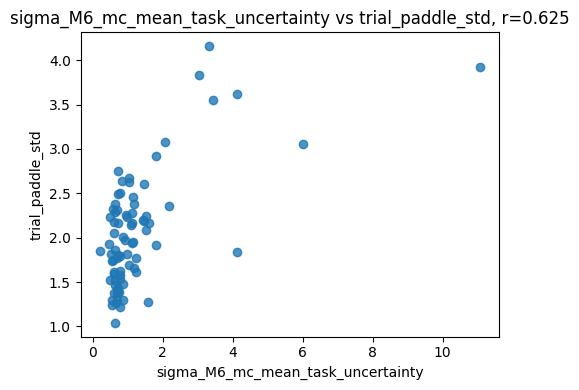

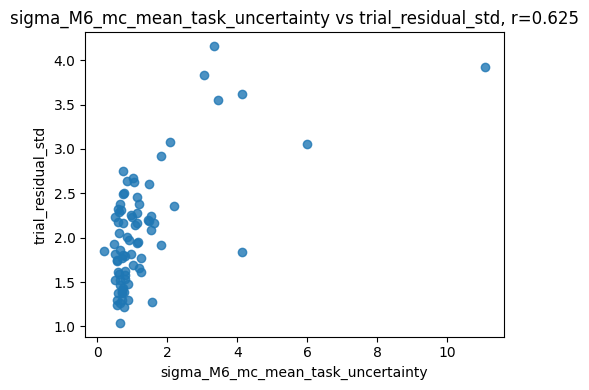

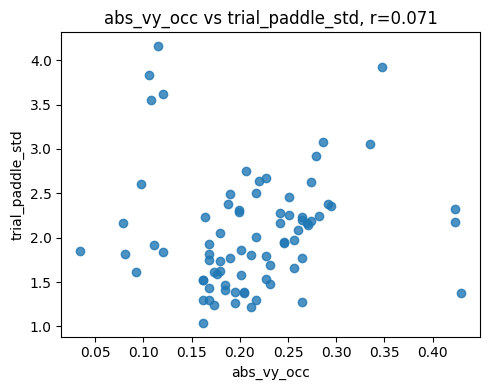

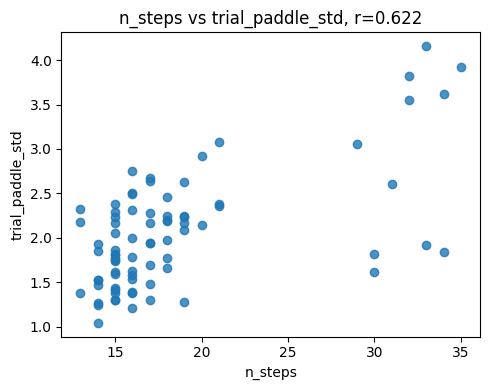

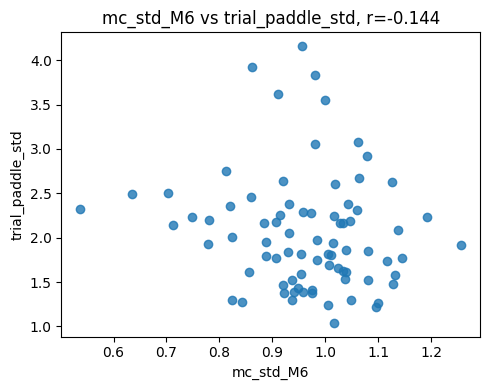

In [ ]:
pairs = [
    ("sigma_M6_mc_mean_task_uncertainty", "trial_paddle_std"),
    ("sigma_M6_mc_mean_task_uncertainty", "trial_residual_std"),
    ("abs_vy_occ", "trial_paddle_std"),
    ("n_steps", "trial_paddle_std"),
    ("mc_std_M6", "trial_paddle_std"),
]

for x_col, y_col in pairs:
    if x_col not in cond_variability.columns or y_col not in cond_variability.columns:
        continue
    
    valid = np.isfinite(cond_variability[x_col]) & np.isfinite(cond_variability[y_col])
    
    if valid.sum() < 5:
        continue
    
    corr = np.corrcoef(
        cond_variability.loc[valid, x_col],
        cond_variability.loc[valid, y_col],
    )[0, 1]
    
    plt.figure(figsize=(5, 4))
    plt.scatter(
        cond_variability.loc[valid, x_col],
        cond_variability.loc[valid, y_col],
        alpha=0.8,
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}, r={corr:.3f}")
    plt.tight_layout()
    plt.show()

In [ ]:
def gaussian_nll(y, mu, sigma, eps=1e-6):
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    sigma = np.maximum(sigma, eps)
    
    return 0.5 * np.log(2 * np.pi * sigma**2) + 0.5 * ((y - mu) / sigma) ** 2


valid_trial = (
    np.isfinite(trial_df["trial_paddle_y"]) &
    np.isfinite(trial_df["y_det"]) &
    np.isfinite(trial_df["pred_M6_mc_mean_task_uncertainty"]) &
    np.isfinite(trial_df["sigma_M6_mc_mean_task_uncertainty"])
)

eval_trial = trial_df.loc[valid_trial].copy()

# M1 trial-level global sigma
eval_trial["mu_M1"] = gain * eval_trial["y_det"] + intercept
sigma_M1_trial = np.sqrt(np.mean((eval_trial["trial_paddle_y"] - eval_trial["mu_M1"]) ** 2))

eval_trial["sigma_M1"] = sigma_M1_trial

# M6
eval_trial["mu_M6"] = eval_trial["pred_M6_mc_mean_task_uncertainty"]
eval_trial["sigma_M6"] = eval_trial["sigma_M6_mc_mean_task_uncertainty"]

eval_trial["nll_M1"] = gaussian_nll(
    eval_trial["trial_paddle_y"],
    eval_trial["mu_M1"],
    eval_trial["sigma_M1"],
)

eval_trial["nll_M6"] = gaussian_nll(
    eval_trial["trial_paddle_y"],
    eval_trial["mu_M6"],
    eval_trial["sigma_M6"],
)

trial_nll_summary = pd.DataFrame([
    {
        "model": "M1_biased_det_global_sigma",
        "mean_nll": eval_trial["nll_M1"].mean(),
        "mae": np.mean(np.abs(eval_trial["trial_paddle_y"] - eval_trial["mu_M1"])),
        "rmse": np.sqrt(np.mean((eval_trial["trial_paddle_y"] - eval_trial["mu_M1"]) ** 2)),
        "sigma": sigma_M1_trial,
        "n_trials": len(eval_trial),
    },
    {
        "model": "M6_mc_mean_task_uncertainty",
        "mean_nll": eval_trial["nll_M6"].mean(),
        "mae": np.mean(np.abs(eval_trial["trial_paddle_y"] - eval_trial["mu_M6"])),
        "rmse": np.sqrt(np.mean((eval_trial["trial_paddle_y"] - eval_trial["mu_M6"]) ** 2)),
        "sigma": eval_trial["sigma_M6"].mean(),
        "n_trials": len(eval_trial),
    },
])

display(trial_nll_summary)

,model,mean_nll,mae,rmse,sigma,n_trials
0,M1_biased_det_global_sigma,2.278317,1.638184,2.361693,2.361693,10158
1,M6_mc_mean_task_uncertainty,4.611195,1.638713,2.362995,1.257765,10158


In [ ]:
TRIAL_BEHAVIOR_PATH = PROCESSED_DIR / "trial_level_behavior_mahler.csv"
COND_VARIABILITY_PATH = PROCESSED_DIR / "condition_trial_behavior_variability_mahler.csv"
TRIAL_NLL_PATH = PROCESSED_DIR / "trial_level_behavior_nll_summary_mahler.csv"
TRIAL_CORR_PATH = PROCESSED_DIR / "trial_behavior_variability_corr_mahler.csv"

trial_df.to_csv(TRIAL_BEHAVIOR_PATH, index=False)
cond_variability.to_csv(COND_VARIABILITY_PATH, index=False)
trial_nll_summary.to_csv(TRIAL_NLL_PATH, index=False)
corr_df.to_csv(TRIAL_CORR_PATH, index=False)

print("Saved:", TRIAL_BEHAVIOR_PATH)
print("Saved:", COND_VARIABILITY_PATH)
print("Saved:", TRIAL_NLL_PATH)
print("Saved:", TRIAL_CORR_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\trial_level_behavior_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\condition_trial_behavior_variability_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\trial_level_behavior_nll_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\trial_behavior_variability_corr_mahler.csv


In [9]:
def gaussian_nll(y, mu, sigma, eps=1e-6):
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    sigma = np.maximum(sigma, eps)

    return 0.5 * np.log(2 * np.pi * sigma**2) + 0.5 * ((y - mu) / sigma) ** 2


def regression_metrics(y, mu):
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)

    valid = np.isfinite(y) & np.isfinite(mu)
    y = y[valid]
    mu = mu[valid]

    return {
        "mae": np.mean(np.abs(y - mu)),
        "rmse": np.sqrt(np.mean((y - mu) ** 2)),
    }


def make_condition_kfold_splits(condition_ids, n_splits=5, seed=42):
    condition_ids = np.asarray(condition_ids)
    unique_conditions = np.array(sorted(np.unique(condition_ids)))

    rng = np.random.default_rng(seed)
    rng.shuffle(unique_conditions)

    folds = np.array_split(unique_conditions, n_splits)

    splits = []

    for fold_conditions in folds:
        test_mask = np.isin(condition_ids, fold_conditions)
        train_mask = ~test_mask

        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]

        splits.append((train_idx, test_idx, fold_conditions))

    return splits


def fit_constant_sigma(y, mu, min_sigma=1e-6):
    sigma = np.sqrt(np.mean((y - mu) ** 2))
    return max(float(sigma), min_sigma)


def fit_calibrated_sigma_grid(
    y,
    mu,
    base_sigma,
    lambda_grid=None,
    sigma0_grid=None,
):
    """
    sigma_total_i = sqrt((lambda * base_sigma_i)^2 + sigma0^2)
    """
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    base_sigma = np.asarray(base_sigma, dtype=float)

    if lambda_grid is None:
        lambda_grid = np.linspace(0.0, 5.0, 101)

    if sigma0_grid is None:
        sigma0_grid = np.linspace(0.1, 5.0, 100)

    best = None

    for lam in lambda_grid:
        for sigma0 in sigma0_grid:
            sigma_total = np.sqrt((lam * base_sigma) ** 2 + sigma0 ** 2)
            mean_nll = np.mean(gaussian_nll(y, mu, sigma_total))

            if best is None or mean_nll < best["mean_nll"]:
                best = {
                    "mean_nll": mean_nll,
                    "lambda": lam,
                    "sigma0": sigma0,
                }

    return best

In [10]:
def evaluate_trial_level_models_cv(trial_df, n_splits=5, seed=42):
    needed = [
        "condition_i",
        "trial_paddle_y",
        "trial_paddle_pred_from_y_det",
        "pred_M6_mc_mean_task_uncertainty",
        "sigma_M6_mc_mean_task_uncertainty",
    ]

    eval_df = trial_df[needed].copy()

    eval_df = eval_df.replace([np.inf, -np.inf], np.nan)
    eval_df = eval_df.dropna()

    eval_df = eval_df[eval_df["sigma_M6_mc_mean_task_uncertainty"] > 0].copy()
    eval_df = eval_df.reset_index(drop=True)

    splits = make_condition_kfold_splits(
        eval_df["condition_i"].values,
        n_splits=n_splits,
        seed=seed,
    )

    rows = []

    for fold, (train_idx, test_idx, test_conditions) in enumerate(splits):
        train = eval_df.iloc[train_idx]
        test = eval_df.iloc[test_idx]

        y_train = train["trial_paddle_y"].values
        y_test = test["trial_paddle_y"].values

        mu_m1_train = train["trial_paddle_pred_from_y_det"].values
        mu_m1_test = test["trial_paddle_pred_from_y_det"].values

        mu_m6_train = train["pred_M6_mc_mean_task_uncertainty"].values
        mu_m6_test = test["pred_M6_mc_mean_task_uncertainty"].values

        sig_m6_train = train["sigma_M6_mc_mean_task_uncertainty"].values
        sig_m6_test = test["sigma_M6_mc_mean_task_uncertainty"].values

        # 1. M1 constant sigma
        sigma_m1 = fit_constant_sigma(y_train, mu_m1_train)
        sigma_test = np.full_like(y_test, sigma_m1)

        rows.append({
            "model": "M1_const_sigma",
            "fold": fold,
            "mean_nll": np.mean(gaussian_nll(y_test, mu_m1_test, sigma_test)),
            **regression_metrics(y_test, mu_m1_test),
            "mean_sigma_test": np.mean(sigma_test),
            "lambda": np.nan,
            "sigma0": sigma_m1,
            "n_train": len(train),
            "n_test": len(test),
        })

        # 2. M6 raw sigma
        rows.append({
            "model": "M6_raw_sigma",
            "fold": fold,
            "mean_nll": np.mean(gaussian_nll(y_test, mu_m6_test, sig_m6_test)),
            **regression_metrics(y_test, mu_m6_test),
            "mean_sigma_test": np.mean(sig_m6_test),
            "lambda": np.nan,
            "sigma0": np.nan,
            "n_train": len(train),
            "n_test": len(test),
        })

        # 3. M6 mean + constant sigma
        sigma_m6_const = fit_constant_sigma(y_train, mu_m6_train)
        sigma_test = np.full_like(y_test, sigma_m6_const)

        rows.append({
            "model": "M6_mean_const_sigma",
            "fold": fold,
            "mean_nll": np.mean(gaussian_nll(y_test, mu_m6_test, sigma_test)),
            **regression_metrics(y_test, mu_m6_test),
            "mean_sigma_test": np.mean(sigma_test),
            "lambda": np.nan,
            "sigma0": sigma_m6_const,
            "n_train": len(train),
            "n_test": len(test),
        })

        # 4. M6 mean + calibrated M6 sigma
        best_m6_cal = fit_calibrated_sigma_grid(
            y=y_train,
            mu=mu_m6_train,
            base_sigma=sig_m6_train,
        )

        sigma_test = np.sqrt(
            (best_m6_cal["lambda"] * sig_m6_test) ** 2
            + best_m6_cal["sigma0"] ** 2
        )

        rows.append({
            "model": "M6_calibrated_sigma",
            "fold": fold,
            "mean_nll": np.mean(gaussian_nll(y_test, mu_m6_test, sigma_test)),
            **regression_metrics(y_test, mu_m6_test),
            "mean_sigma_test": np.mean(sigma_test),
            "lambda": best_m6_cal["lambda"],
            "sigma0": best_m6_cal["sigma0"],
            "n_train": len(train),
            "n_test": len(test),
        })

        # 5. M1 mean + calibrated M6 sigma
        best_m1_cal = fit_calibrated_sigma_grid(
            y=y_train,
            mu=mu_m1_train,
            base_sigma=sig_m6_train,
        )

        sigma_test = np.sqrt(
            (best_m1_cal["lambda"] * sig_m6_test) ** 2
            + best_m1_cal["sigma0"] ** 2
        )

        rows.append({
            "model": "M1_mean_M6_calibrated_sigma",
            "fold": fold,
            "mean_nll": np.mean(gaussian_nll(y_test, mu_m1_test, sigma_test)),
            **regression_metrics(y_test, mu_m1_test),
            "mean_sigma_test": np.mean(sigma_test),
            "lambda": best_m1_cal["lambda"],
            "sigma0": best_m1_cal["sigma0"],
            "n_train": len(train),
            "n_test": len(test),
        })

    cv_df = pd.DataFrame(rows)

    summary = (
        cv_df
        .groupby("model")
        .agg(
            mean_nll=("mean_nll", "mean"),
            sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            mean_mae=("mae", "mean"),
            mean_rmse=("rmse", "mean"),
            mean_sigma_test=("mean_sigma_test", "mean"),
            mean_lambda=("lambda", "mean"),
            mean_sigma0=("sigma0", "mean"),
        )
        .reset_index()
        .sort_values("mean_nll")
    )

    return cv_df, summary, eval_df

In [12]:
# 1. 현재 trial_df column 확인
print("trial_df columns containing paddle:")
print([c for c in trial_df.columns if "paddle" in c])

print("\ntrial_df columns containing y_det / M6:")
print([c for c in trial_df.columns if ("y_det" in c) or ("M6" in c)])

trial_df columns containing paddle:
['paddle_pos_x_from_mwk', 'paddle_pos_y_from_mwk', 'paddle_y', 'paddle_error', 'paddle_error_signed', 'y_paddle']

trial_df columns containing y_det / M6:
['y_det', 'pred_M6_mc_mean_task_uncertainty', 'sigma_M6_mc_mean_task_uncertainty', 'mc_mean_M6', 'mc_std_M6']


In [13]:
# 1. trial-level paddle column 찾기
candidate_trial_paddle_cols = [
    "paddle_y",
    "paddle_y_x",
    "paddle_y_trial",
    "paddle_pos_y",
    "paddle_pos_y_from_mwk",
]

trial_paddle_col = None

for c in candidate_trial_paddle_cols:
    if c in trial_df.columns:
        trial_paddle_col = c
        break

if trial_paddle_col is None:
    # fallback: paddle 들어간 column 전부 보여주고 에러
    paddle_cols = [c for c in trial_df.columns if "paddle" in c]
    print("Available paddle-related columns:")
    print(paddle_cols)
    raise ValueError("No trial-level paddle column found. Choose the correct column manually.")

print("Using trial-level paddle column:", trial_paddle_col)

trial_df["trial_paddle_y"] = trial_df[trial_paddle_col]


# 2. behavior condition table 다시 로드/확인
# beh_cond 또는 beh가 이미 있으면 그걸 써도 됨.
if "beh_cond" not in globals():
    beh_cond = pd.read_csv(PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv")

print("beh_cond columns containing y_det / y_paddle / M6:")
print([c for c in beh_cond.columns if ("y_det" in c) or ("y_paddle" in c) or ("M6" in c)])


# 3. trial_df에 y_det / M6 prediction이 없으면 다시 merge
needed_from_beh = [
    "condition_i",
    "y_det",
    "y_true",
    "y_paddle",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
]

needed_from_beh = [c for c in needed_from_beh if c in beh_cond.columns]

missing_needed = [
    c for c in needed_from_beh
    if c != "condition_i" and c not in trial_df.columns
]

if len(missing_needed) > 0:
    print("Merging missing columns from beh_cond:", missing_needed)
    
    # 중복 column 있으면 제거 후 merge
    drop_cols = [c for c in needed_from_beh if c != "condition_i" and c in trial_df.columns]
    trial_df = trial_df.drop(columns=drop_cols, errors="ignore")
    
    trial_df = trial_df.merge(
        beh_cond[needed_from_beh],
        on="condition_i",
        how="left",
    )

print("After merge, available:")
print([c for c in trial_df.columns if ("y_det" in c) or ("y_true" in c) or ("M6" in c)])


# 4. y_det 기반 biased deterministic prediction 만들기
valid = np.isfinite(beh_cond["y_det"]) & np.isfinite(beh_cond["y_paddle"])

coef = np.polyfit(
    beh_cond.loc[valid, "y_det"],
    beh_cond.loc[valid, "y_paddle"],
    deg=1,
)

gain = coef[0]
intercept = coef[1]

trial_df["trial_paddle_pred_from_y_det"] = (
    gain * trial_df["y_det"] + intercept
)

trial_df["trial_paddle_residual_from_y_det"] = (
    trial_df["trial_paddle_y"] - trial_df["trial_paddle_pred_from_y_det"]
)

trial_df["trial_paddle_error_from_true"] = (
    trial_df["trial_paddle_y"] - trial_df["y_true"]
)

print("gain:", gain)
print("intercept:", intercept)

# 5. 최종 확인
required_cols = [
    "condition_i",
    "trial_paddle_y",
    "trial_paddle_pred_from_y_det",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
]

missing = [c for c in required_cols if c not in trial_df.columns]

print("Missing required cols:", missing)

display(
    trial_df[
        [c for c in required_cols + ["y_det", "y_true", "trial_paddle_residual_from_y_det"]
         if c in trial_df.columns]
    ].head()
)

assert len(missing) == 0, f"Still missing columns: {missing}"

Using trial-level paddle column: paddle_y
beh_cond columns containing y_det / y_paddle / M6:
['y_det', 'y_paddle', 'abs_y_det', 'pred_M6_mc_mean_task_uncertainty', 'sigma_M6_mc_mean_task_uncertainty', 'mc_mean_M6', 'mc_std_M6']
After merge, available:
['y_det', 'y_true', 'pred_M6_mc_mean_task_uncertainty', 'sigma_M6_mc_mean_task_uncertainty', 'mc_mean_M6', 'mc_std_M6']
gain: 0.8736645456633193
intercept: -0.21198693774335028
Missing required cols: []


,condition_i,trial_paddle_y,trial_paddle_pred_from_y_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,y_det,y_true,trial_paddle_residual_from_y_det
0,43,6.97,5.082109,5.044052,0.501301,6.059644,6.059645,1.887891
1,57,2.89,2.102637,2.030133,1.139117,2.649327,2.649328,0.787363
2,23,-2.38,-3.531315,-3.325373,0.612957,-3.799316,-3.799317,1.151315
3,6,2.38,5.281925,5.430527,0.702931,6.288353,6.288354,-2.901925
4,37,2.72,4.393158,4.293258,0.597892,5.271068,5.271068,-1.673158


In [14]:
trial_cv, trial_calibrated_summary, eval_trial_df = evaluate_trial_level_models_cv(
    trial_df=trial_df,
    n_splits=5,
    seed=42,
)

display(trial_calibrated_summary)
display(trial_cv)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_sigma_test,mean_lambda,mean_sigma0
2,M6_calibrated_sigma,2.233951,0.017834,1.636706,2.354823,2.340110,0.86,1.931313
1,M1_mean_M6_calibrated_sigma,2.234101,0.018228,1.636214,2.353418,2.340110,0.86,1.931313
0,M1_const_sigma,2.279511,0.033072,1.636214,2.353418,2.361147,NaN,2.361147
3,M6_mean_const_sigma,2.280070,0.032885,1.636706,2.354823,2.362458,NaN,2.362458
4,M6_raw_sigma,4.626791,0.875125,1.636706,2.354823,1.248604,NaN,NaN


,model,fold,mean_nll,mae,rmse,mean_sigma_test,lambda,sigma0,n_train,n_test
0,M1_const_sigma,0,2.219836,1.554324,2.214294,2.396963,NaN,2.396963,8134,2024
1,M6_raw_sigma,0,3.839238,1.547095,2.219461,1.342562,NaN,NaN,8134,2024
2,M6_mean_const_sigma,0,2.221855,1.547095,2.219461,2.397376,NaN,2.397376,8134,2024
3,M6_calibrated_sigma,0,2.195049,1.547095,2.219461,2.453890,0.95,1.931313,8134,2024
4,M1_mean_M6_calibrated_sigma,0,2.190938,1.554324,2.214294,2.453890,0.95,1.931313,8134,2024
5,M1_const_sigma,1,2.197677,1.550826,2.152990,2.410820,NaN,2.410820,8134,2024
6,M6_raw_sigma,1,8.054070,1.556243,2.150356,0.774957,NaN,NaN,8134,2024
7,M6_mean_const_sigma,1,2.196887,1.556243,2.150356,2.412996,NaN,2.412996,8134,2024
8,M6_calibrated_sigma,1,2.187742,1.556243,2.150356,2.025702,0.90,1.881818,8134,2024
9,M1_mean_M6_calibrated_sigma,1,2.189289,1.550826,2.152990,2.025702,0.90,1.881818,8134,2024
